# Penguins - exploratory data analysis

Quick look at the raw dataset that feeds the pipeline
(`data/raw/penguins.csv`, Palmer Penguins). The findings here motivate the
cleaning rules in `services/airflow/dags/data_engineering.py`.

In [1]:
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "services" / "airflow" / "dags"))

raw = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "penguins.csv")
raw.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## Shape, dtypes and missing values

In [2]:
print(raw.shape)
raw.info()
raw.isna().sum()

(344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Two rows miss every measurement and 11 rows miss `sex`; the raw file also
uses `.` as an unknown-sex marker. The cleaning step imputes numeric columns
with the median and categorical columns with the mode.

## Class balance and descriptive statistics

In [3]:
display(raw["species"].value_counts())
display(raw.groupby("species")[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].mean())
raw.describe()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


## Feature separability

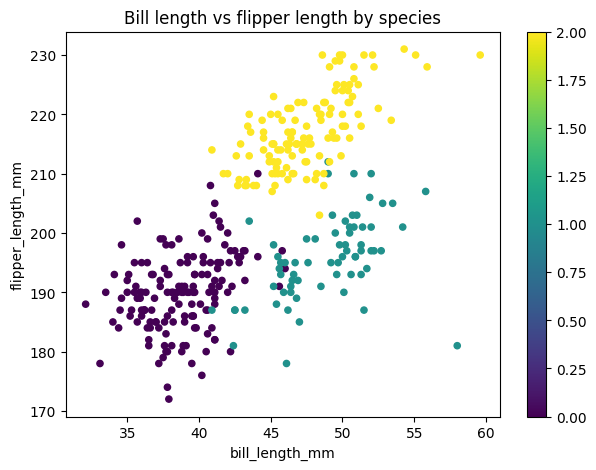

In [4]:
ax = raw.plot.scatter(
    x="bill_length_mm",
    y="flipper_length_mm",
    c=raw["species"].astype("category").cat.codes,
    cmap="viridis",
    figsize=(7, 5),
    title="Bill length vs flipper length by species",
)

Bill length combined with flipper length separates the three species almost
linearly, which is why even a small random forest reaches ~98% test accuracy.

## Output of the cleaning step

In [5]:
from data_engineering import clean_data, load_data

clean = clean_data(load_data())
print(f"raw rows: {len(raw)} -> clean rows: {len(clean)}")
clean.isna().sum()

raw rows: 344 -> clean rows: 344


species              0
island               0
sex                  0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64